# 🌸 Iris Flower Classification

## Objective

The objective of this project is to classify Iris flowers into three species using machine learning algorithms and compare their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

Load the Iris dataset

In [2]:
iris = load_iris()

print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

# **Creating a DataFrame**

To make the dataset easier to analyze, I converted it into a Pandas DataFrame and added the species column.

In [18]:
# Create a DataFrame from the Iris dataset
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column (flower species)
df['species'] = iris.target

# Display the first 5 rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 150
Number of Columns: 5


**Species Distribution**

The dataset contains 150 flower samples.

Each species (Setosa, Versicolor, and Virginica) has 50 samples, which means the dataset is balanced and suitable for training a classification model.

In [21]:
print("Number of flowers in each species:")
print(df['species'].value_counts())

Number of flowers in each species:
species
0    50
1    50
2    50
Name: count, dtype: int64


**Converting Target Values to Species Names**

The target column originally contains numerical values (0, 1, and 2).

To make the dataset easier to understand, these values are converted into their corresponding flower species names:
- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

In [6]:
# Replace numerical labels with flower species names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})
# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Data Visualization**

A scatter plot is used to visualize the relationship between sepal length and petal length.

Each point on the graph represents a flower sample. This helps us observe patterns and understand how the features vary across the dataset.

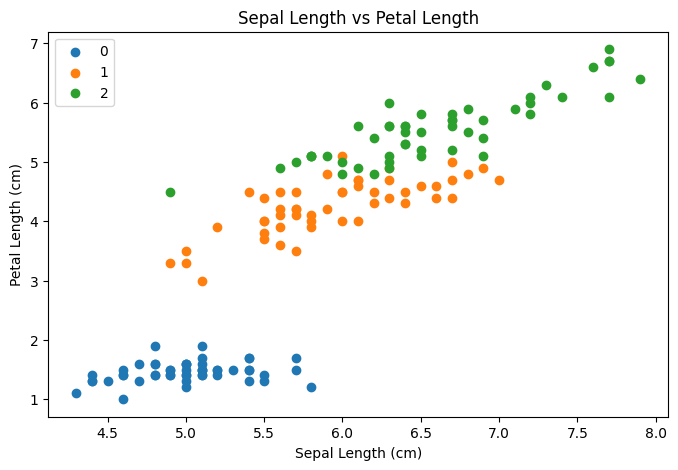

In [23]:
# Create a scatter plot to compare sepal length and petal length

plt.figure(figsize=(8,5))

for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.scatter(
        subset['sepal length (cm)'],
        subset['petal length (cm)'],
        label=species
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length")
plt.legend()

plt.show()

**Preparing Features and Target**

For machine learning, the dataset is divided into:

- X (Features): Flower measurements such as sepal length, sepal width, petal length, and petal width.
- y (Target): The species of the flower.

The model uses the features to learn patterns and predict the target species.

In [24]:
# Input features (flower measurements)
X = iris.data

# Target variable (flower species)
y = iris.target

**Train-Test Split**

The dataset is divided into training and testing sets.

- Training Data (80%) is used to train the model.
- Testing Data (20%) is used to evaluate the model.

This helps measure how well the model performs on unseen data and prevents overfitting.

In [26]:
# Split the dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% data for testing
    random_state=42    # ensures consistent results
)

**Model Comparison**

In [27]:
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
#KNN
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

In [29]:
#Logistic Regression
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

In [30]:
#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

In [31]:
#RAndom Forest
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

In [15]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Class:", prediction)
print("Flower:", iris.target_names[prediction][0])

Predicted Class: [0]
Flower: setosa


## Comparing Multiple Machine Learning Models

Instead of using only one algorithm, I compared four different classification models:

- K-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree
- Random Forest

The goal was to identify which algorithm performs best on the Iris dataset.

In [32]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        knn_accuracy,
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,KNN,1.0
1,Logistic Regression,1.0
2,Decision Tree,1.0
3,Random Forest,1.0


## Results and Observations

Four classification algorithms were tested on the Iris dataset:

| Model | Accuracy |
|---------|---------|
| KNN | 100% |
| Logistic Regression | 100% |
| Decision Tree | 100% |
| Random Forest | 100% |

### Observation

All four models achieved 100% accuracy on the test dataset.

This indicates that the Iris dataset is relatively simple and well-structured, making it easy for multiple classification algorithms to distinguish between the three flower species.

For this project, KNN was chosen as the primary model because of its simplicity and ease of understanding.

In [33]:
# Find the best performing model

best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       KNN
Accuracy    1.0
Name: 0, dtype: object


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, knn_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Conclusion

In this project, I explored the Iris dataset and applied multiple machine learning classification algorithms.

The workflow included:
- Data loading
- Data preprocessing
- Data visualization
- Train-test splitting
- Model training
- Accuracy evaluation

All tested models achieved 100% accuracy on the test set, demonstrating that the Iris dataset is well-suited for classification tasks.

This project helped me understand the complete machine learning pipeline and compare the performance of different classification algorithms.